In [7]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from sklearn.preprocessing import MinMaxScaler
from tensorflow import keras

### 1.import data

In [8]:
fd001=pd.read_csv('/mnt/c/Users/PC/Downloads/AI/DeepLearning/Data PreProcessing/CLEANED_DATA/train/train_FD001_cleaned.csv',sep=',')
fd002=pd.read_csv('/mnt/c/Users/PC/Downloads/AI/DeepLearning/Data PreProcessing/CLEANED_DATA/train/train_FD002_cleaned.csv',sep=',')
fd003=pd.read_csv('/mnt/c/Users/PC/Downloads/AI/DeepLearning/Data PreProcessing/CLEANED_DATA/train/train_FD003_cleaned.csv',sep=',')
fd004=pd.read_csv('/mnt/c/Users/PC/Downloads/AI/DeepLearning/Data PreProcessing/CLEANED_DATA/train/train_FD004_cleaned.csv',sep=',')


In [9]:
print(len(fd001.columns))
print(len(fd002.columns))
print(len(fd003.columns))
print(len(fd004.columns))

20
20
20
20


In [10]:
test_df=pd.read_csv('/mnt/c/Users/PC/Downloads/AI/DeepLearning/FINAL transformer  PROJECT/data cleaning/test_FD001_cleaned.csv',sep=',')
rul_true=pd.read_csv('/mnt/c/Users/PC/Downloads/AI/DeepLearning/FINAL transformer  PROJECT/not ready datasets/not ready datasets/RUL_FD001.txt',header=None,names=["RUL"],sep=',')
print(rul_true)
print(fd001['id'])

    RUL
0   112
1    98
2    69
3    82
4    91
..  ...
95  137
96   82
97   59
98  117
99   20

[100 rows x 1 columns]
0          1
1          1
2          1
3          1
4          1
        ... 
20626    100
20627    100
20628    100
20629    100
20630    100
Name: id, Length: 20631, dtype: int64


### 2.data preprocessing

In [11]:
#scaling

def scaling_process(df):
    y=df['RUL']
    y_clipped = y.clip(upper=125)
    df['RUL']=y_clipped
    feature_cols=[col for col in df.columns if not col in ['id','cycle','setting3']]
    x=df[feature_cols]
    indexes=df[feature_cols]
    x_scaler=MinMaxScaler()
    x_scaled=x_scaler.fit_transform(x)
    scaled_df=pd.DataFrame(
        x_scaled,
        columns=feature_cols,
        index=indexes.index
    )
    scaled_df['id']=df['id']
    return scaled_df,x_scaler

In [12]:
#2.windowing
def windows(df,rul_true=None,seq_len=44):#seq len should be even number
    feature_cols=[col for col in df.columns if not col in ['id','cycle','setting3']]
    X=[]
    y=[]
    
    for engine ,engine_data in df.groupby('id'):
        engine_feats=engine_data[feature_cols].values
        if len(engine_data)>= seq_len:
            if 'RUL' in df.columns:
                engine_rul=engine_data['RUL'].values
            
                for i in range (len(engine_data) - seq_len+1):
                    X.append(engine_feats[i : i + seq_len])
                    
            else:
                
                X.append(engine_feats[- seq_len :])
                y.append(rul_true.loc[engine-1])

        

    return np.array(X),np.array(y)

In [13]:
fd001_scaled,fd001_scaler = scaling_process(fd001)
fd002_scaled,fd002_scaler = scaling_process(fd002)
fd003_scaled,fd003_scaler = scaling_process(fd003)
fd004_scaled,fd004_scaler = scaling_process(fd004)

In [32]:
print(fd001_scaled.columns)

Index(['RUL', 'setting1', 'setting2', 'sensor_2', 'sensor_3', 'sensor_4',
       'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12',
       'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20',
       'sensor_21', 'id'],
      dtype='object')


In [14]:
x1_train,y1_train=windows(fd001_scaled)
x2_train,y2_train=windows(fd002_scaled)
x3_train,y3_train=windows(fd003_scaled)
x4_train,y4_train=windows(fd004_scaled)

In [15]:
print(f"fd001 Training data shape: {x1_train.shape}") 
print(f"fd002 Training data shape: {x2_train.shape}") 
print(f"fd003 Training data shape: {x3_train.shape}") 
print(f"fd004 Training data shape: {x4_train.shape}") 

fd001 Training data shape: (16331, 44, 17)
fd002 Training data shape: (42579, 44, 17)
fd003 Training data shape: (20420, 44, 17)
fd004 Training data shape: (50542, 44, 17)


### 3.Initializing and Training the VAE

In [16]:
from VAE_base import BaseVariationalAutoencoder , Sampling
seq_len=x1_train.shape[1]
feat_dim= x1_train.shape[2]
latent_dim = 32
batch_size= 32

In [17]:
model = BaseVariationalAutoencoder(seq_len=seq_len,feat_dim=feat_dim,latent_dim=latent_dim,batch_size=batch_size)
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001))

model.fit_on_data(x1_train,max_epochs=500,verbose=1)


2026-04-14 19:34:06.374324: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:966] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-14 19:34:06.465795: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:966] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-14 19:34:06.465861: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:966] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-14 19:34:06.466644: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow 

Epoch 1/500


2026-04-14 19:34:35.979207: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8101
2026-04-14 19:34:50.200665: I tensorflow/stream_executor/cuda/cuda_blas.cc:1614] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


511/511 [==============================] - 57s 46ms/step - loss: 43.8868 - reconstruction_loss: 10.1979 - kl_loss: 2.2961 - lr: 0.0010
Epoch 2/500
511/511 [==============================] - 24s 48ms/step - loss: 25.4599 - reconstruction_loss: 7.6864 - kl_loss: 2.1026 - lr: 0.0010
Epoch 3/500
511/511 [==============================] - 28s 55ms/step - loss: 23.8896 - reconstruction_loss: 7.0244 - kl_loss: 2.6815 - lr: 0.0010
Epoch 4/500
511/511 [==============================] - 21s 41ms/step - loss: 23.3714 - reconstruction_loss: 6.8192 - kl_loss: 2.7193 - lr: 0.0010
Epoch 5/500
511/511 [==============================] - 18s 36ms/step - loss: 22.9106 - reconstruction_loss: 6.7157 - kl_loss: 2.7358 - lr: 0.0010
Epoch 6/500
511/511 [==============================] - 21s 41ms/step - loss: 22.8528 - reconstruction_loss: 6.6982 - kl_loss: 2.7443 - lr: 0.0010
Epoch 7/500
511/511 [==============================] - 18s 36ms/step - loss: 22.7949 - reconstruction_loss: 6.6794 - kl_loss: 2.7357 - 

KeyboardInterrupt: 

In [18]:
trainable_params , non_trainable_params , total_params= model.get_num_trainable_variables()
print(f"trainable parameters : {trainable_params }")
print(f"non trainable parameters : {non_trainable_params }")
print(f"total parameters : {total_params }")

trainable parameters : 96401
non trainable parameters : 6
total parameters : 96407


### 4.Saving and Loading

In [19]:
import os
model.save("BaseVAE_full.h5")

model_dir= os.getcwd()
model.save(model_dir)
model.save_weights(model_dir)
model.load_weights(model_dir)

### 5.Generating Synthetic Data

In [20]:
num_samples=5000
samples=model.get_prior_samples(num_samples=num_samples)
print(f"Shape of generated data: {samples.shape}") 

# 2. Inverse Transform back to real-world physics
samples_2D=samples.reshape(-1,feat_dim)
samples_T=fd001_scaler.inverse_transform(samples_2D)

samples_3D=samples_T.reshape(num_samples,seq_len,feat_dim)


Shape of generated data: (5000, 44, 17)


In [21]:
# 2. Inverse Transform back to real-world physics
x1_train_2D=x1_train.reshape(-1,feat_dim)
x1_train_T=fd001_scaler.inverse_transform(x1_train_2D)
num_samples_real=x1_train.shape[0]
x1_train_3D=x1_train_T.reshape(num_samples_real,seq_len,feat_dim)


In [22]:
import joblib
np.save("vae_generated_data.npy", samples_3D)
joblib.dump(fd001_scaler,"vae_scaler_fd001.pkl")


['vae_scaler_fd001.pkl']

In [23]:
samples_3D = np.load("vae_generated_data.npy")

## Evaluation of the synthetic data
Wasserstein Distance (WD):
Good: < 0.05 (Distributions are virtually identical).
Bad: > 0.20 (The VAE failed to capture the upper and lower limits of the sensors; the synthetic engines might be generating impossible temperatures).

Mean Correlation Error:
Good: < 0.10. The heatmap should look almost entirely white/very pale pink. This means if Sensor A and B move together in real life, they also move together in the synthetic data.
Bad: > 0.30. If the heatmap has dark red squares, it means the VAE is breaking physics (e.g., generating high temperatures with low pressure, which might be thermodynamically impossible).

Rate of Change (Derivatives):
If the red curve is much wider than the blue curve, your synthetic data is too "noisy" or "jittery" (jumping up and down wildly between cycles).
If the red curve perfectly matches the blue curve, your VAE successfully learned the exact, smooth physical rate of engine degradation.

In [24]:
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wasserstein_distance

In [25]:
def flatten_data(data):
    """Flattens 3D time-series data to 2D for statistical comparison."""
    return data.reshape(-1, data.shape[2])

In [26]:
def plot_all_feature_distributions(real_data, synthetic_data, feature_names):
    # Flatten the 3D data to 2D
    real_2d = real_data.reshape(-1, real_data.shape[2])
    synth_2d = synthetic_data.reshape(-1, synthetic_data.shape[2])
    num_features = real_2d.shape[1]
    
    # Calculate a dynamic grid size (4 columns wide)
    cols = 4
    rows = math.ceil(num_features / cols)
    
    # Create the figure
    fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
    axes = axes.flatten() # Flatten axes to loop through them easily
    
    w_distances =[]
    
    for i in range(num_features):
        # Calculate Wasserstein Distance
        wd = wasserstein_distance(real_2d[:, i], synth_2d[:, i])
        w_distances.append(wd)
        
        # Plot KDEs
        sns.kdeplot(real_2d[:, i], ax=axes[i], fill=True, color='blue', label='Real')
        sns.kdeplot(synth_2d[:, i], ax=axes[i], fill=True, color='red', label='Synthetic')
        
        # Set Title and Legend
        name = feature_names[i] if feature_names else f"Sensor {i}"
        axes[i].set_title(f"{name} (WD: {wd:.4f})")
        axes[i].legend()
        
    # If the number of features isn't perfectly divisible by 4, 
    # we need to hide the empty, unused subplots at the end.
    for j in range(num_features, len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()


In [27]:
def plot_correlation_difference(real_data, synthetic_data):
    real_2d = flatten_data(real_data)
    synth_2d = flatten_data(synthetic_data)
    
    # Calculate correlation matrices
    real_corr = np.corrcoef(real_2d, rowvar=False)
    synth_corr = np.corrcoef(synth_2d, rowvar=False)
    
    # Calculate the absolute difference between them
    corr_diff = np.abs(real_corr - synth_corr)
    
    # Mean Error in Correlation (Physics Score)
    mean_diff = np.mean(corr_diff)
    print(f"Mean Correlation Error (Closer to 0 is better physics): {mean_diff:.4f}")
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_diff, cmap="Reds", vmin=0, vmax=1)
    plt.title(f"Correlation Error Heatmap (Mean Error: {mean_diff:.4f})")
    plt.xlabel("Sensors")
    plt.ylabel("Sensors")
    plt.show()

In [28]:
def compare_temporal_derivatives(real_data, synthetic_data, sensor_idx=0):
    # Calculate step-to-step changes (Current cycle minus Previous cycle)
    real_diff = np.diff(real_data, axis=1)      # Shape: (Batch, 43, Features)
    synth_diff = np.diff(synthetic_data, axis=1)
    
    # Flatten just the specific sensor
    real_diff_flat = real_diff[:, :, sensor_idx].flatten()
    synth_diff_flat = synth_diff[:, :, sensor_idx].flatten()
    
    plt.figure(figsize=(8, 5))
    sns.kdeplot(real_diff_flat, fill=True, color='blue', label='Real Rate of Change')
    sns.kdeplot(synth_diff_flat, fill=True, color='red', label='Synthetic Rate of Change')
    plt.title(f"Physics Check: Temporal Rate of Change (Sensor {sensor_idx})")
    plt.xlabel("Step-to-Step Change (Delta)")
    plt.legend()
    plt.show()

In [29]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

   
def visualization (ori_data, generated_data, analysis):
  """Using PCA or tSNE for generated and original data visualization.
  
  Args:
    - ori_data: original data
    - generated_data: generated synthetic data
    - analysis: tsne or pca
  """  
  # Analysis sample size (for faster computation)
  anal_sample_no = min([1000, len(generated_data)])
  idx = np.random.permutation(len(generated_data))[:anal_sample_no]
    
  # Data preprocessing
  ori_data = np.asarray(ori_data)
  generated_data = np.asarray(generated_data)  
  
  ori_data = ori_data[idx]
  generated_data = generated_data[idx]
  
  no, seq_len, dim = ori_data.shape  
  
  for i in range(anal_sample_no):
    if (i == 0):
      prep_data = np.reshape(np.mean(ori_data[0,:,:], 1), [1,seq_len])
      prep_data_hat = np.reshape(np.mean(generated_data[0,:,:],1), [1,seq_len])
    else:
      prep_data = np.concatenate((prep_data, 
                                  np.reshape(np.mean(ori_data[i,:,:],1), [1,seq_len])))
      prep_data_hat = np.concatenate((prep_data_hat, 
                                      np.reshape(np.mean(generated_data[i,:,:],1), [1,seq_len])))
    
  # Visualization parameter        
  colors = ["red" for i in range(anal_sample_no)] + ["blue" for i in range(anal_sample_no)]    
    
  if analysis == 'pca':
    # PCA Analysis
    pca = PCA(n_components = 2)
    pca.fit(prep_data)
    pca_results = pca.transform(prep_data)
    pca_hat_results = pca.transform(prep_data_hat)
    
    # Plotting
    f, ax = plt.subplots(1)    
    plt.scatter(pca_results[:,0], pca_results[:,1],
                c = colors[:anal_sample_no], alpha = 0.2, label = "Original")
    plt.scatter(pca_hat_results[:,0], pca_hat_results[:,1], 
                c = colors[anal_sample_no:], alpha = 0.2, label = "Synthetic")
  
    ax.legend()  
    plt.title('PCA plot')
    plt.xlabel('x-pca')
    plt.ylabel('y_pca')
    plt.show()
    
  elif analysis == 'tsne':
    
    # Do t-SNE Analysis together       
    prep_data_final = np.concatenate((prep_data, prep_data_hat), axis = 0)
    
    # TSNE anlaysis
    tsne = TSNE(n_components = 2, verbose = 1, perplexity = 40)
    tsne_results = tsne.fit_transform(prep_data_final)
      
    # Plotting
    f, ax = plt.subplots(1)
      
    plt.scatter(tsne_results[:anal_sample_no,0], tsne_results[:anal_sample_no,1], 
                c = colors[:anal_sample_no], alpha = 0.2, label = "Original")
    plt.scatter(tsne_results[anal_sample_no:,0], tsne_results[anal_sample_no:,1], 
                c = colors[anal_sample_no:], alpha = 0.2, label = "Synthetic")
  
    ax.legend()
      
    plt.title('t-SNE plot')
    plt.xlabel('x-tsne')
    plt.ylabel('y_tsne')
    plt.show()    

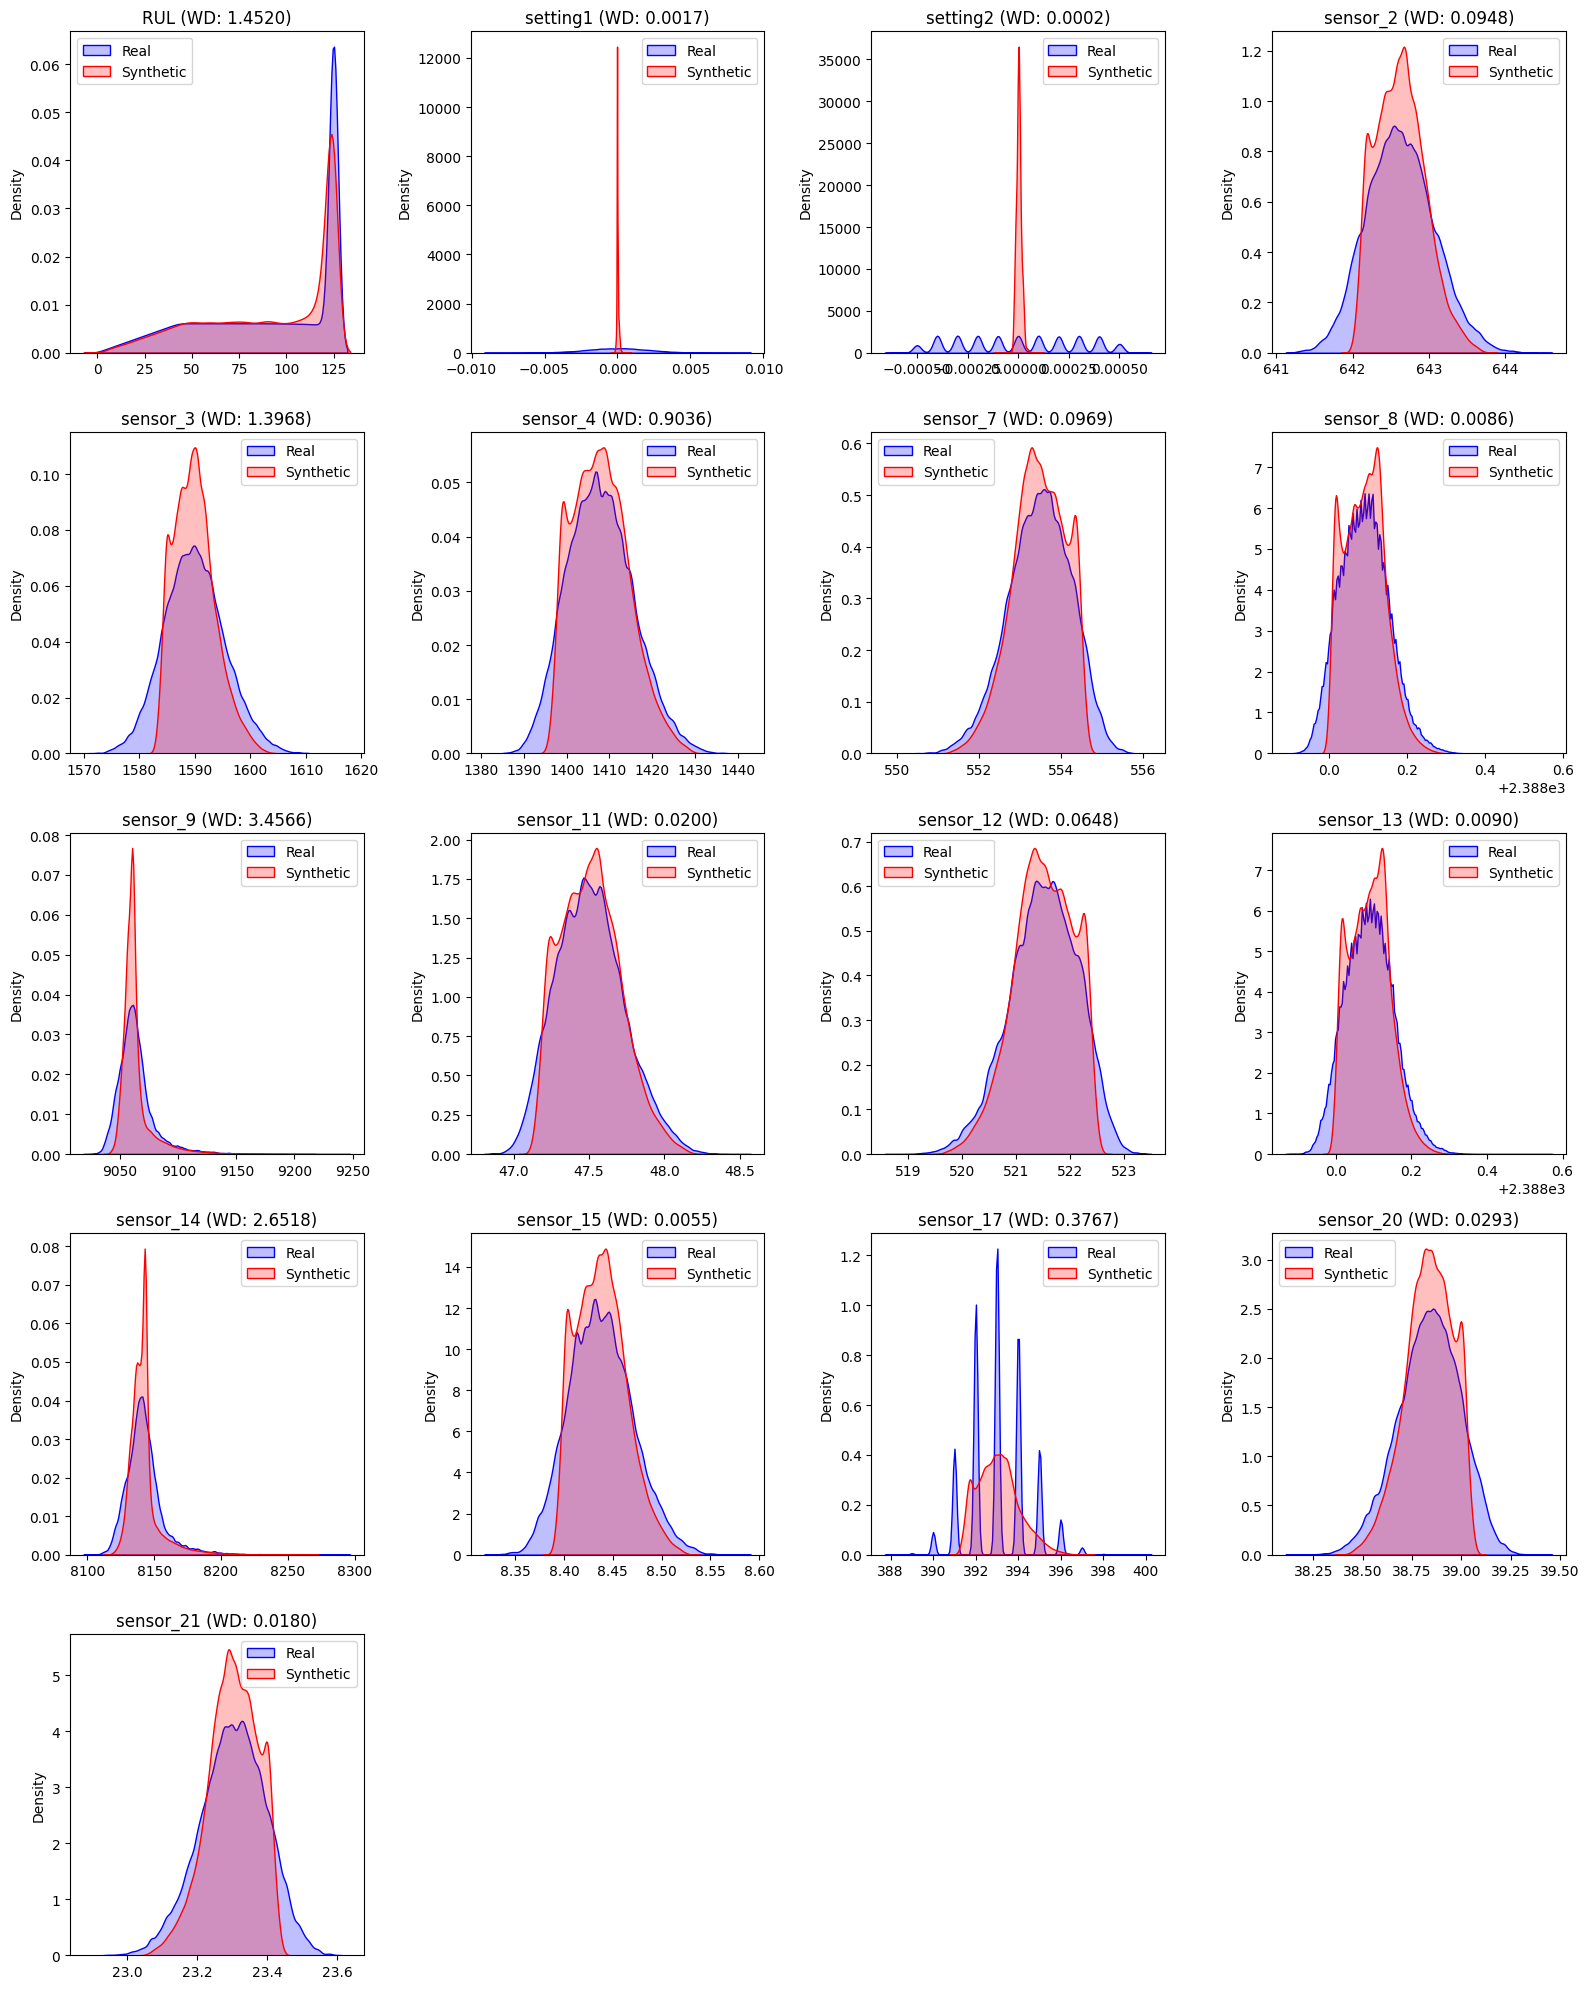

Mean Correlation Error (Closer to 0 is better physics): 0.2746


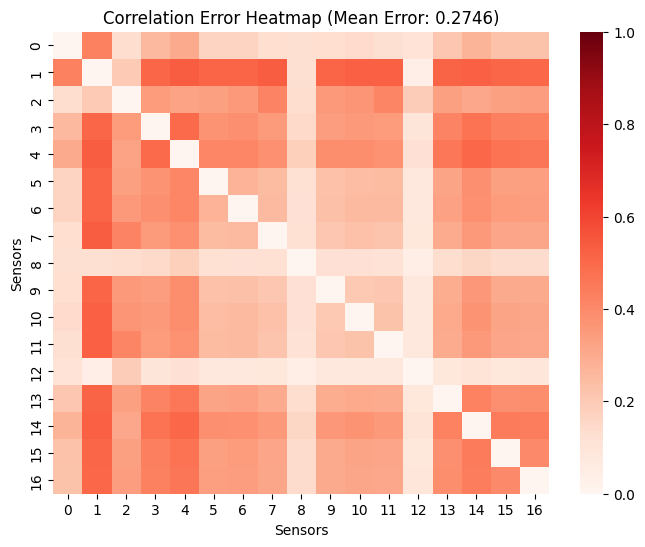

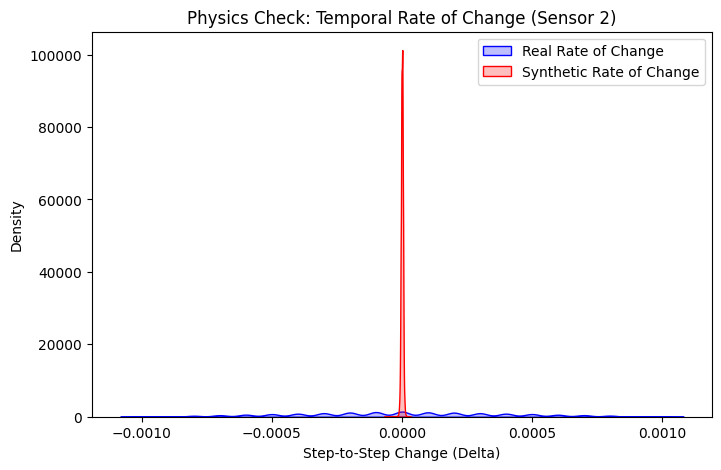

In [30]:
feature_cols=[col for col in fd001.columns if not col in ['id','cycle','setting3']]
active_features=feature_cols
plot_all_feature_distributions(x1_train_3D, samples_3D, active_features)
plot_correlation_difference(x1_train_3D, samples_3D)
compare_temporal_derivatives(x1_train_3D, samples_3D, sensor_idx=2)


[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 2000 samples in 0.001s...
[t-SNE] Computed neighbors for 2000 samples in 0.295s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2000
[t-SNE] Computed conditional probabilities for sample 2000 / 2000
[t-SNE] Mean sigma: 0.474185
[t-SNE] KL divergence after 250 iterations with early exaggeration: 57.077538
[t-SNE] KL divergence after 1000 iterations: 0.628215


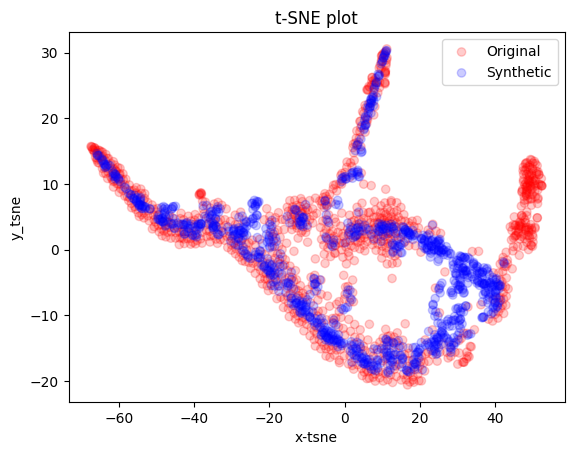

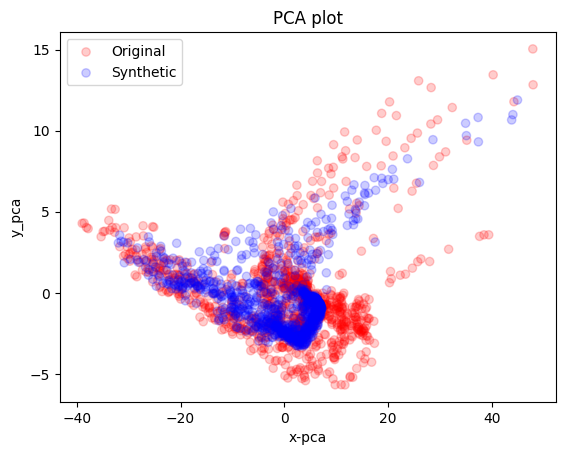

In [31]:
visualization (x1_train_3D, samples_3D, 'tsne')
visualization (x1_train_3D, samples_3D, 'pca')